# Exploratory Data Analysis — CEAS 2008 Phishing Email Dataset

**Dataset:** `CEAS_08.csv` — 39,154 emails collected for the CEAS 2008 phishing-detection benchmark.

**Problem type:** Binary Classification — predict whether an email is **phishing/spam (`label`=1)** or **legitimate (`label`=0)**.

This notebook covers:
- **Part 2 — Initial Data Exploration**
- **Part 4 — Exploratory Data Analysis** (Numerical, Categorical, and Relationship analysis + insights)


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_colwidth', 80)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('CEAS_08.csv')
df.shape


(39154, 7)

## Part 2 — Initial Data Exploration

### 2.1 Dataset shape, columns, data types

In [2]:
print(f"Rows: {df.shape[0]:,}    Columns: {df.shape[1]}")
print()
print(df.dtypes)


Rows: 39,154    Columns: 7

sender        str
receiver      str
date          str
subject       str
body          str
label       int64
urls        int64
dtype: object


### 2.2 First few records

In [3]:
df.head(3)


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimension will soon be over!\nBecome ...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these techniques http://www.brightmade...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet.psi.br>,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP...,1,1


### 2.3 Summary statistics

In [4]:
# Numerical columns
df.describe(include=[np.number])


,label,urls
count,39154.000000,39154.00000
mean,0.557848,0.66997
std,0.496649,0.47023
min,0.000000,0.00000
25%,0.000000,0.00000
50%,1.000000,1.00000
75%,1.000000,1.00000
max,1.000000,1.00000


In [5]:
# Object/text columns
df.describe(include=['object'])


/tmp/ipykernel_647/2117689639.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,sender,receiver,date,subject,body
count,39154,38692,39154,39126,39154
unique,24578,3693,38658,15436,39154
top,qydlqcws-iacfym@issues.apache.org,user6@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 21:38:18 -0100",CNN.com Daily Top 10,"Buck up, your troubles caused by small dimension will soon be over!\nBecome ..."
freq,462,1375,8,2930,1


### 2.4 Missing values (quick check — full treatment belongs to Part 3)

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')


,missing_count,missing_pct
receiver,462,1.18
subject,28,0.07


### 2.5 Duplicate rows

In [7]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Rows with duplicate email body:", df.duplicated(subset=['body']).sum())


Fully duplicated rows: 0
Rows with duplicate email body: 0


### 2.6 Target distribution

/tmp/ipykernel_647/16045079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, ax=ax[0], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_647/16045079.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'])


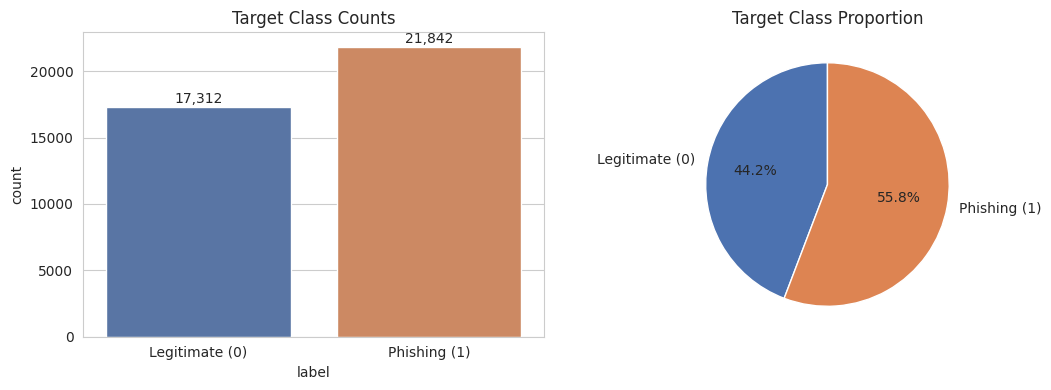

label
0    44.22
1    55.78
Name: proportion, dtype: float64


In [8]:
label_counts = df['label'].value_counts().sort_index()
label_pct = df['label'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='label', data=df, ax=ax[0], palette=['#4C72B0', '#DD8452'])
ax[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'])
ax[0].set_title('Target Class Counts')
for i, v in enumerate(label_counts):
    ax[0].text(i, v + 300, f"{v:,}", ha='center')

ax[1].pie(label_pct, labels=['Legitimate (0)', 'Phishing (1)'], autopct='%1.1f%%',
          colors=['#4C72B0', '#DD8452'], startangle=90)
ax[1].set_title('Target Class Proportion')
plt.tight_layout()
plt.show()

print(label_pct.round(2))


**Observations — Part 2:**

- The dataset has **39,154 rows and 7 columns**: `sender`, `receiver`, `date`, `subject`, `body`, `label`, `urls`.
- Each row represents **one email message**.
- `label` and `urls` are the only truly numeric columns (both are actually binary flags stored as `int64`); `sender`, `receiver`, `date`, `subject`, `body` are free text — most of the "features" here need to be *engineered* from text before they're usable numerically.
- Missing values exist only in `receiver` (~1.2%) and `subject` (~0.07%) — small enough to be easy to handle, and a missing `subject` is itself potentially informative (phishing emails sometimes omit one).
- No fully duplicated rows and no duplicate email bodies — the dataset is not artificially inflated.
- The target is **mildly imbalanced**: ~55.8% phishing (1) vs. ~44.2% legitimate (0). This isn't severe, but it's still worth watching — Accuracy alone could mildly overstate performance, so Precision/Recall/F1/AUC will matter more than plain Accuracy later.
- `date` is stored as a string, not a datetime — it will need parsing to extract useful features (hour, day of week).
- `sender`/`receiver` contain full "Name <email@domain>" strings, so the raw column isn't directly usable — the **domain** is the useful signal buried inside it.


## Part 4 — Exploratory Data Analysis

Raw text columns (`subject`, `body`, `sender`) aren't directly plottable, so we first engineer a handful of lightweight numeric/categorical features purely for EDA purposes (formal feature engineering for modeling happens in Part 5).

In [9]:
eda = df.copy()

# Text-length features
eda['subject_len']   = eda['subject'].fillna('').str.len()
eda['body_len']      = eda['body'].fillna('').str.len()
eda['body_word_ct']  = eda['body'].fillna('').str.split().str.len()

# Simple lexical signals often associated with phishing
eda['subject_excl_ct']   = eda['subject'].fillna('').str.count('!')
eda['subject_upper_ratio'] = eda['subject'].fillna('').apply(
    lambda s: sum(1 for c in s if c.isupper()) / len(s) if len(s) > 0 else 0)

# Sender domain
eda['sender_domain'] = eda['sender'].fillna('').str.extract(r'@([\w\.-]+)')[0].str.lower()

# Date parsing -> hour of day / day of week
eda['date_parsed'] = pd.to_datetime(eda['date'], errors='coerce', utc=True)
eda['send_hour']   = eda['date_parsed'].dt.hour
eda['send_dow']    = eda['date_parsed'].dt.day_name()

eda[['subject_len','body_len','body_word_ct','subject_excl_ct','subject_upper_ratio','sender_domain','send_hour']].head(3)


,subject_len,body_len,body_word_ct,subject_excl_ct,subject_upper_ratio,sender_domain,send_hour
0,25,273,46,0,0.040000,iworld.de,23.0
1,22,82,9,0,0.136364,icable.ph,23.0
2,20,3918,302,0,0.250000,universalnet.psi.br,8.0


### 4.1 Numerical Analysis

In [10]:
num_cols = ['subject_len', 'body_len', 'body_word_ct', 'subject_excl_ct', 'subject_upper_ratio']
eda[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
subject_len,39154.0,38.896537,20.769595,0.0,25.000000,35.000000,50.000000,285.0
body_len,39154.0,1571.079813,3615.810576,14.0,224.000000,570.000000,1643.000000,143996.0
body_word_ct,39154.0,202.034964,479.926431,1.0,35.000000,89.000000,247.000000,19863.0
subject_excl_ct,39154.0,0.069623,0.304665,0.0,0.000000,0.000000,0.000000,4.0
subject_upper_ratio,39154.0,0.117112,0.102781,0.0,0.037736,0.088235,0.176471,1.0


In [11]:
from scipy.stats import skew

print("Skewness of numerical features:")
for c in num_cols:
    print(f"  {c:22s}: {skew(eda[c].dropna()):.2f}")


Skewness of numerical features:
  subject_len           : 1.44
  body_len              : 11.23
  body_word_ct          : 12.89
  subject_excl_ct       : 5.33
  subject_upper_ratio   : 1.79


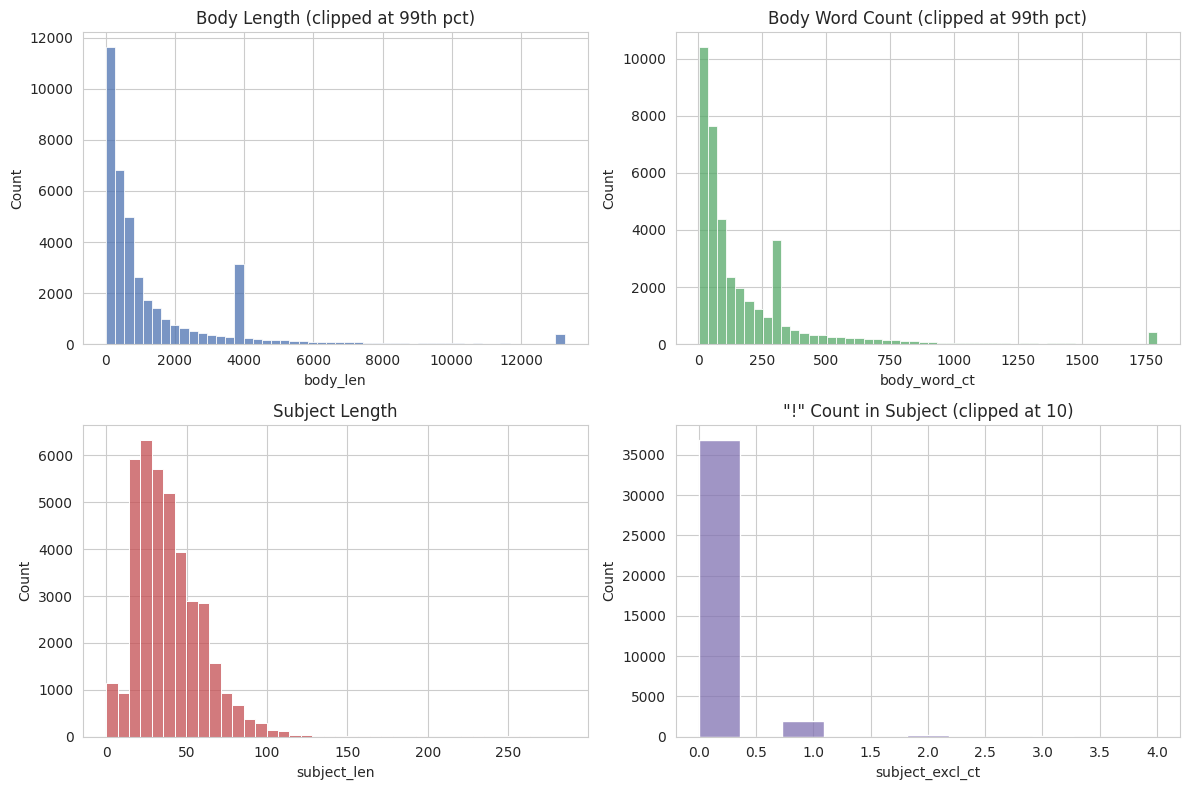

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(eda['body_len'].clip(upper=eda['body_len'].quantile(0.99)), bins=50, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Body Length (clipped at 99th pct)')

sns.histplot(eda['body_word_ct'].clip(upper=eda['body_word_ct'].quantile(0.99)), bins=50, ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Body Word Count (clipped at 99th pct)')

sns.histplot(eda['subject_len'], bins=40, ax=axes[1,0], color='#C44E52')
axes[1,0].set_title('Subject Length')

sns.histplot(eda['subject_excl_ct'].clip(upper=10), bins=11, ax=axes[1,1], color='#8172B2')
axes[1,1].set_title('"!" Count in Subject (clipped at 10)')

plt.tight_layout()
plt.show()


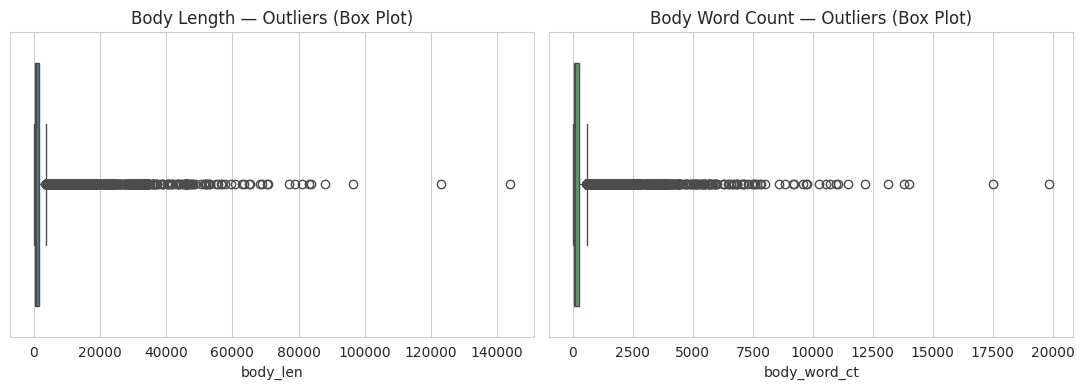

body_len: 5,622 outliers by IQR rule (14.4% of rows), bounds=(-1904, 3772)
body_word_ct: 2,478 outliers by IQR rule (6.3% of rows), bounds=(-283, 565)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=eda['body_len'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Body Length — Outliers (Box Plot)')
sns.boxplot(x=eda['body_word_ct'], ax=axes[1], color='#55A868')
axes[1].set_title('Body Word Count — Outliers (Box Plot)')
plt.tight_layout()
plt.show()

# IQR-based outlier count
for c in ['body_len', 'body_word_ct']:
    q1, q3 = eda[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((eda[c] < lo) | (eda[c] > hi)).sum()
    print(f"{c}: {n_out:,} outliers by IQR rule ({n_out/len(eda)*100:.1f}% of rows), bounds=({lo:.0f}, {hi:.0f})")


**Numerical Analysis — what we observe:**
- `body_len` and `body_word_ct` are both **strongly right-skewed** (skewness well above 1) — a small number of very long emails pull the mean far above the median. This is typical for free text and means **median-based summaries and log-transforms** are more informative than the raw mean.
- `subject_len` is roughly symmetric and much less skewed.
- The IQR rule flags a meaningful chunk of "outliers" in body length/word count, but these are almost certainly **legitimate long emails** (newsletters, forwarded threads) rather than data errors — so they should be **kept**, not removed, and a log-transform is the more appropriate treatment for modeling later.
- `subject_excl_ct` is heavily zero-inflated — most subjects have no `!`, but a real subset has several, which is worth checking against the target below.


### 4.2 Categorical Analysis

In [14]:
print("`urls` flag distribution:")
print(eda['urls'].value_counts())
print((eda['urls'].value_counts(normalize=True) * 100).round(2))


`urls` flag distribution:
urls
1    26232
0    12922
Name: count, dtype: int64
urls
1    67.0
0    33.0
Name: proportion, dtype: float64


In [15]:
top_domains = eda['sender_domain'].value_counts().head(15)
top_domains


sender_domain
gmail.com                2638
python.org                537
issues.apache.org         462
v.loewis.de               289
massey.ac.nz              284
google.com                239
telefonica.net            209
lists.techtarget.com      199
gvc.ceas-challenge.cc     193
yahoo.com                 185
hotpop.com                183
perl.org                  177
pobox.com                 165
cheimes.de                155
hotmail.com               146
Name: count, dtype: int64

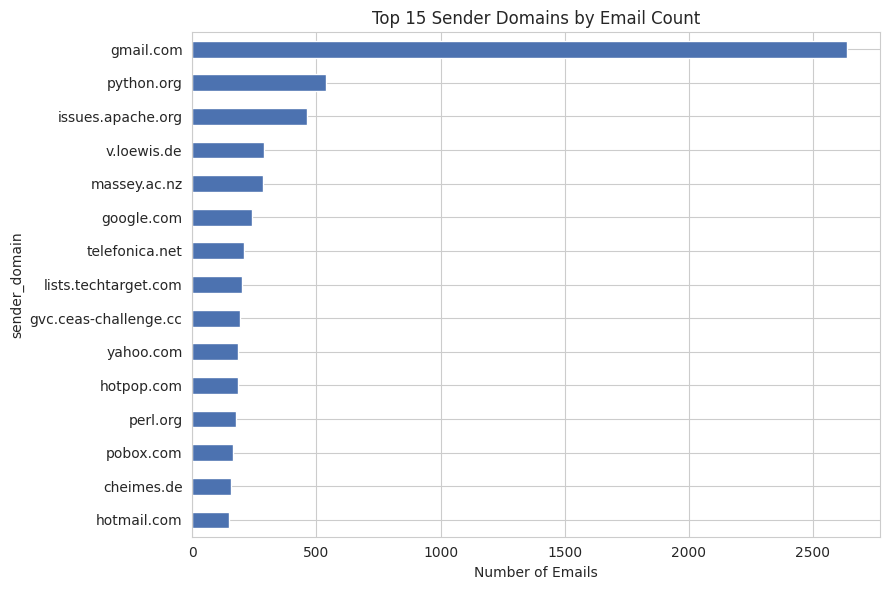

Number of distinct sender domains: 16,817


In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
top_domains.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 Sender Domains by Email Count')
ax.set_xlabel('Number of Emails')
plt.tight_layout()
plt.show()

print(f"Number of distinct sender domains: {eda['sender_domain'].nunique():,}")


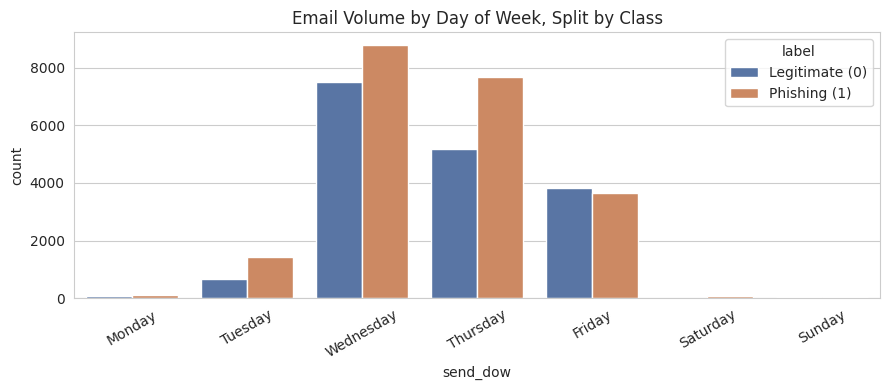

In [17]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(x='send_dow', data=eda, order=dow_order, hue='label', ax=ax, palette=['#4C72B0','#DD8452'])
ax.set_title('Email Volume by Day of Week, Split by Class')
ax.legend(title='label', labels=['Legitimate (0)', 'Phishing (1)'])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Categorical Analysis — what we observe:**
- About **68% of all emails contain a URL** (`urls`=1) — this is a strong candidate feature since phishing emails typically rely on a malicious link.
- Sender domains are extremely **high-cardinality** (many thousands of distinct domains) with a long tail — a handful of domains send many emails, but most domains appear only once or twice. Raw domain is too sparse to use directly as a categorical feature and would need grouping (e.g., known-provider vs. unknown, or frequency-encoding) in Part 5.
- Email volume by day of week is fairly stable, with no single day dramatically dominating — day-of-week alone looks like a **weak** signal, though it's shown split by class above to check for any interaction.


### 4.3 Relationship Analysis

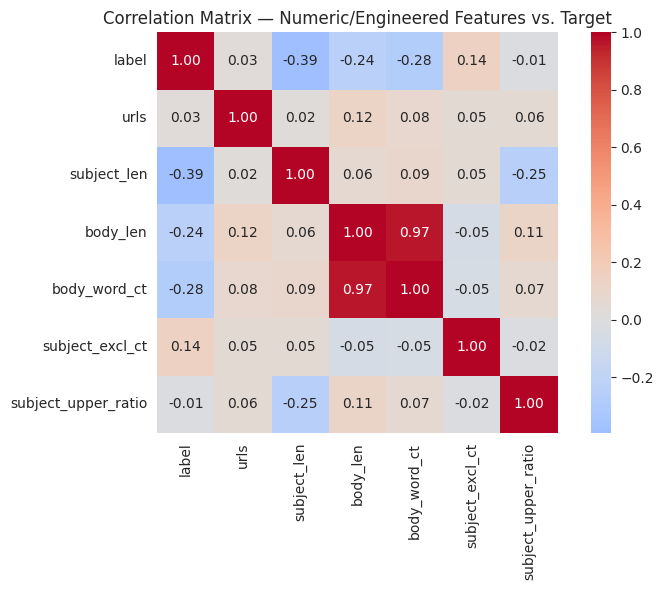

label                  1.000000
subject_excl_ct        0.135426
urls                   0.027945
subject_upper_ratio   -0.012958
body_len              -0.239108
body_word_ct          -0.276607
subject_len           -0.393834
Name: label, dtype: float64

In [18]:
corr_cols = ['label', 'urls', 'subject_len', 'body_len', 'body_word_ct', 'subject_excl_ct', 'subject_upper_ratio']
corr = eda[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Numeric/Engineered Features vs. Target')
plt.tight_layout()
plt.show()

corr['label'].sort_values(ascending=False)


In [19]:
# Feature vs Target: urls
pivot_urls = pd.crosstab(eda['urls'], eda['label'], normalize='index') * 100
pivot_urls.columns = ['Legitimate %', 'Phishing %']
pivot_urls.index = ['No URL', 'Has URL']
pivot_urls


,Legitimate %,Phishing %
No URL,46.19254,53.80746
Has URL,43.24108,56.75892


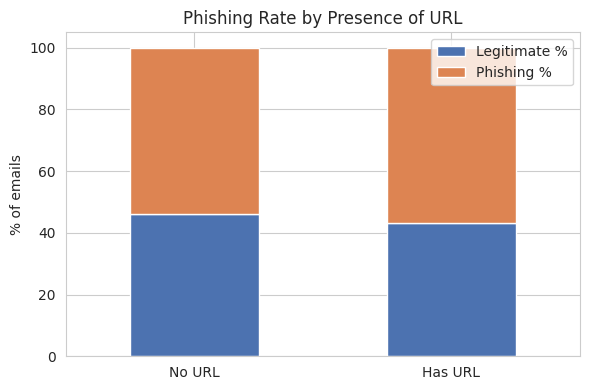

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
pivot_urls.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Phishing Rate by Presence of URL')
ax.set_ylabel('% of emails')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/tmp/ipykernel_647/2757045583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=eda['body_len'].clip(upper=eda['body_len'].quantile(0.95)), data=eda, ax=ax,
/tmp/ipykernel_647/2757045583.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Legitimate (0)', 'Phishing (1)'])


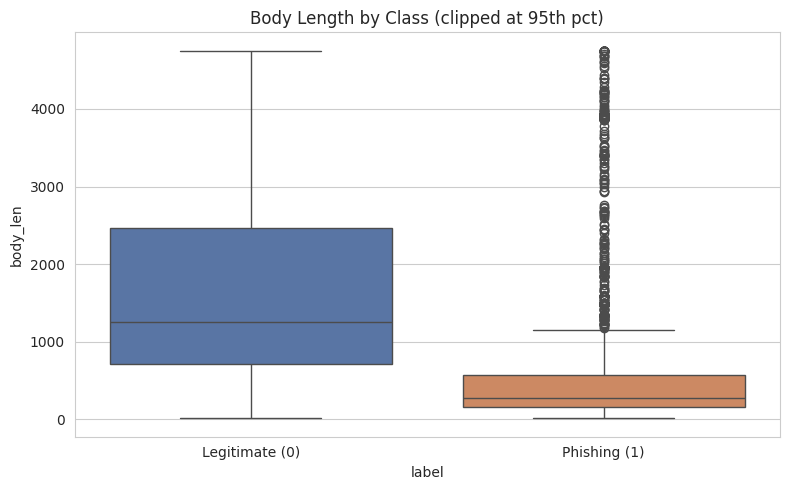

,body_len,body_word_ct,subject_len
label,,,
0,1252.0,187.0,45.0
1,278.0,42.0,27.0


In [21]:
# Feature vs Target: body length (box plot by class)
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='label', y=eda['body_len'].clip(upper=eda['body_len'].quantile(0.95)), data=eda, ax=ax,
            palette=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['Legitimate (0)', 'Phishing (1)'])
ax.set_title('Body Length by Class (clipped at 95th pct)')
plt.tight_layout()
plt.show()

eda.groupby('label')[['body_len','body_word_ct','subject_len']].median()


/tmp/ipykernel_647/124988037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=eda['subject_excl_ct'].clip(upper=5), data=eda, ax=axes[0],


/tmp/ipykernel_647/124988037.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'])
/tmp/ipykernel_647/124988037.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='subject_upper_ratio', data=eda, ax=axes[1], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_647/124988037.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Legitimate (0)', 'Phishing (1)'])


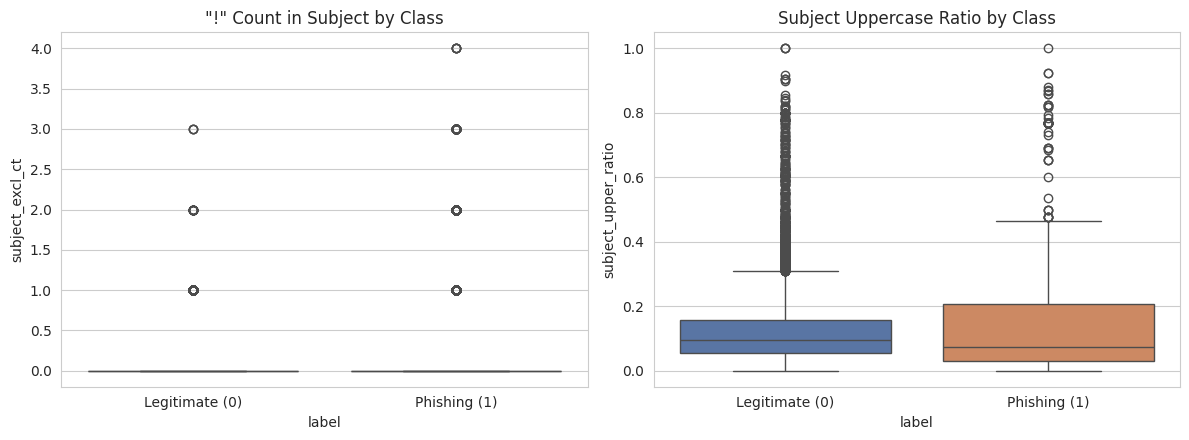

In [22]:
# Feature vs Target: subject "!" count and uppercase ratio
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x='label', y=eda['subject_excl_ct'].clip(upper=5), data=eda, ax=axes[0],
            palette=['#4C72B0', '#DD8452'])
axes[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'])
axes[0].set_title('"!" Count in Subject by Class')

sns.boxplot(x='label', y='subject_upper_ratio', data=eda, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_xticklabels(['Legitimate (0)', 'Phishing (1)'])
axes[1].set_title('Subject Uppercase Ratio by Class')

plt.tight_layout()
plt.show()


In [23]:
# Pivot table: mean feature values by class
eda.pivot_table(index='label', values=['urls','body_len','body_word_ct','subject_len',
                                        'subject_excl_ct','subject_upper_ratio'], aggfunc='mean').round(2)


,body_len,body_word_ct,subject_excl_ct,subject_len,subject_upper_ratio,urls
label,,,,,,
0,2542.19,351.14,0.02,48.08,0.12,0.66
1,801.38,83.85,0.11,31.61,0.12,0.68


**Relationship Analysis — what we observe:**
- **`subject_len` has the strongest linear correlation with the target of any engineered feature (r ≈ -0.39)**, followed by `body_word_ct` (r ≈ -0.28) and `body_len` (r ≈ -0.24) — all negative. Phishing emails tend to have **both shorter subjects and shorter bodies** than legitimate emails (median body ~42 words vs. ~187 words for legitimate mail). This is a genuinely useful, moderately strong signal, though it likely behaves more like a **threshold/nonlinear** effect than a clean straight line.
- `body_len` and `body_word_ct` are (unsurprisingly) almost perfectly correlated with each other (r ≈ 0.97) — for modeling, only one of the two is needed to avoid redundant/collinear features.
- **`urls`** correlates positively but only mildly with `label` in the raw correlation matrix — both classes contain a majority of emails with links, so on its own it's a **weak-to-moderate** signal; it's more useful combined with other features than alone.
- **`subject_upper_ratio`** and **`subject_excl_ct`** are higher on average for phishing emails, consistent with the "urgency"/marketing-style subject lines the phishing class often uses — a plausible, moderately weak signal.
- None of the engineered numeric features show a strong linear correlation with `label` individually (all |r| are modest), which is expected: this is fundamentally a **text classification problem**, so the raw `subject`/`body` text (via TF-IDF or embeddings) will carry far more predictive power than these summary statistics. These engineered features are still useful as **auxiliary/meta features** alongside the text.


### Key EDA Insights (Summary)

1. **The target is mildly imbalanced (56% phishing / 44% legitimate)** — not severe enough to require resampling, but Accuracy alone would be a misleading metric; Precision, Recall, F1, and ROC-AUC should be reported and prioritized in evaluation.
2. **Email length is the strongest engineered signal found**: `subject_len` is the most correlated engineered feature with the target (r ≈ -0.39), and phishing bodies are typically much shorter (median ~42 words) than legitimate bodies (median ~187 words) — suggesting the raw text and its length statistics will both carry real predictive power.
3. **Body length and body word count are heavily right-skewed, near-perfectly collinear with each other (r ≈ 0.97), and have legitimate long-tail outliers** (long newsletters/threads) — so only one of the two should be kept as a feature, and a log-transform is more appropriate than outlier removal.
4. **`urls` alone is a weak signal** — the majority of both phishing and legitimate emails contain a link (68% vs 66%), so presence of a URL is common to both classes and only mildly discriminative on its own; it will likely need to be combined with URL *content* features (domain reputation, shortened links, etc.) for real lift, which is outside this dataset's raw columns.
5. **Sender domain is high-cardinality and sparse**, so it cannot be used directly as a categorical predictor — it will need grouping/frequency-encoding in Part 5 rather than one-hot encoding as-is.
6. **Subjects with more "!" and higher uppercase ratios skew slightly toward phishing**, consistent with the urgency/hype tone typical of phishing subject lines, but the effect is modest on its own.
7. **This is primarily a text-classification problem** — none of the structured/engineered numeric features individually correlate strongly with the target, which tells us the raw `subject` and `body` text content (via TF-IDF, embeddings, or similar) should be the dominant input to the models built in later parts, with the engineered features (length, urls, punctuation style) serving as useful auxiliary signals.
